# 2. Budowa i trening modeli uczenia maszynowego

1. Konfiguracja

In [7]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             mean_squared_error, mean_absolute_error, r2_score)
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

2. Definicja funkcji do trenowania modeli

In [8]:
def train_models(filepath='/dane_obrobka_cnc.csv'):
    print("--- ETAP 3: INICJALIZACJA MODELOWANIA XGBOOST ---")
    df = pd.read_csv(filepath)

    # PRZYGOTOWANIE DANYCH
    # Zamiana błędu czujnika (-99.0) na NaN. XGBoost natywnie radzi sobie z brakami danych!
    df['Temp_Chlodziwa_Mean_C'] = df['Temp_Chlodziwa_Mean_C'].replace(-99.0, np.nan)

    # Zdefiniowanie cech wejściowych (X). Odrzucenie identyfikatorów oraz wszystkich zmiennych docelowych
    features_to_drop = ['ID_Czesci', 'ID_Narzedzia', 'Awaria_Narzedzia',
                        'Chropowatosc_Ra', 'Odchylenie_Wymiarowe', 'Klasa_Jakosci']
    X = df.drop(columns=features_to_drop)

    # MODEL 1: KLASYFIKACJA (Klasa Jakości)
    print("\nTrenowanie Modelu Klasyfikacji (Klasa_Jakosci)...")

    le = LabelEncoder()
    y_class = le.fit_transform(df['Klasa_Jakosci'])

    # Podział na zbiór treningowy i testowy
    # Stratify stosuje się dla niezbalansowanych zbiorów, żeby zbiór treningowy i testowy miał podobną ilość części róznych klas
    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
        X, y_class, test_size=0.2, random_state=42, stratify=y_class
    )

    # Konfiguracja i trening klasyfikatora
    clf = xgb.XGBClassifier(
        n_estimators=150,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        missing=np.nan
    )
    clf.fit(X_train_c, y_train_c)

    # Ewaluacja Klasyfikatora
    y_pred_c = clf.predict(X_test_c)
    print("\n--- Raport Klasyfikacji (Zbiór Testowy) ---")
    print(classification_report(y_test_c, y_pred_c, target_names=le.classes_))

    # MODEL 2: REGRESJA (Chropowatość Ra)
    print("\nTrenowanie Modelu Regresji (Chropowatosc_Ra)...")
    y_reg = df['Chropowatosc_Ra']

    # Podział danych, brak stratify bo to zmienna ciągła
    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
        X, y_reg, test_size=0.2, random_state=42
    )

    # Konfiguracja i trening regresora
    reg = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=150,
        max_depth=4,
        learning_rate=0.05,
        random_state=42,
        missing=np.nan
    )
    reg.fit(X_train_r, y_train_r)

    # Ewaluacja Regresora
    y_pred_r = reg.predict(X_test_r)
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
    mae = mean_absolute_error(y_test_r, y_pred_r)
    r2 = r2_score(y_test_r, y_pred_r)

    print("\n--- Metryki Regresji (Zbiór Testowy) ---")
    print(f"RMSE (Błąd średniokwadratowy): {rmse:.4f} µm")
    print(f"MAE (Średni błąd bezwzględny): {mae:.4f} µm")
    print(f"R^2 (Współczynnik determinacji): {r2:.4f}")

    # Feature Importance
    print("\nGenerowanie wykresów ważności cech (Feature Importance)...")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Feature Importance dla Klasyfikatora
    xgb.plot_importance(clf, ax=axes[0], importance_type='gain', max_num_features=10,
                        height=0.6, title='Ważność Cech - Klasyfikator Jakości',
                        xlabel='F-Score (Zysk informacyjny)', color='steelblue')

    # Feature Importance dla Regresora
    xgb.plot_importance(reg, ax=axes[1], importance_type='gain', max_num_features=10,
                        height=0.6, title='Ważność Cech - Regresor (Chropowatość Ra)',
                        xlabel='F-Score (Zysk informacyjny)', color='darkorange')

    plt.tight_layout()
    plt.savefig('waznosc_cech_xgboost.png', bbox_inches='tight')
    plt.show()

    print("Modelowanie zakończone! Wykres zapisany jako 'waznosc_cech_xgboost.png'.")

    print("Generowanie wykresów ewaluacyjnych...")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Macierz Pomyłek
    cm = confusion_matrix(y_test_c, y_pred_c)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                ax=axes[0], cbar=False, annot_kws={"size": 14})
    axes[0].set_title('Macierz Pomyłek (Confusion Matrix) - Klasyfikacja', fontsize=14, pad=15)
    axes[0].set_ylabel('Wartość Rzeczywista', fontweight='bold')
    axes[0].set_xlabel('Wartość Przewidywana przez Model', fontweight='bold')

    # Wykres Reszt
    residuals = y_test_r - y_pred_r
    sns.scatterplot(x=y_pred_r, y=residuals, alpha=0.4, color='teal', ax=axes[1])
    axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[1].set_title('Wykres Reszt (Residuals Plot) - Regresja Ra', fontsize=14, pad=15)
    axes[1].set_xlabel('Przewidywana Chropowatość Ra [µm]', fontweight='bold')
    axes[1].set_ylabel('Błąd predykcji (Rzeczywista - Przewidywana) [µm]', fontweight='bold')

    plt.tight_layout()
    plt.savefig('wykresy_ewaluacyjne.png', bbox_inches='tight')
    plt.show()
    print("Zakończono! Wykres zapisany jako 'wykresy_ewaluacyjne.png'.")

--- ETAP 3: INICJALIZACJA MODELOWANIA XGBOOST ---

Trenowanie Modelu Klasyfikacji (Klasa_Jakosci)...

--- Raport Klasyfikacji (Zbiór Testowy) ---
              precision    recall  f1-score   support

  Do_Poprawy       0.92      0.93      0.93      3919
          OK       0.86      0.85      0.86      2077
        Zlom       1.00      0.25      0.40         4

    accuracy                           0.90      6000
   macro avg       0.93      0.68      0.73      6000
weighted avg       0.90      0.90      0.90      6000


Trenowanie Modelu Regresji (Chropowatosc_Ra)...

--- Metryki Regresji (Zbiór Testowy) ---
RMSE (Błąd średniokwadratowy): 0.1594 µm
MAE (Średni błąd bezwzględny): 0.0852 µm
R^2 (Współczynnik determinacji): 0.7837

Generowanie wykresów ważności cech (Feature Importance)...


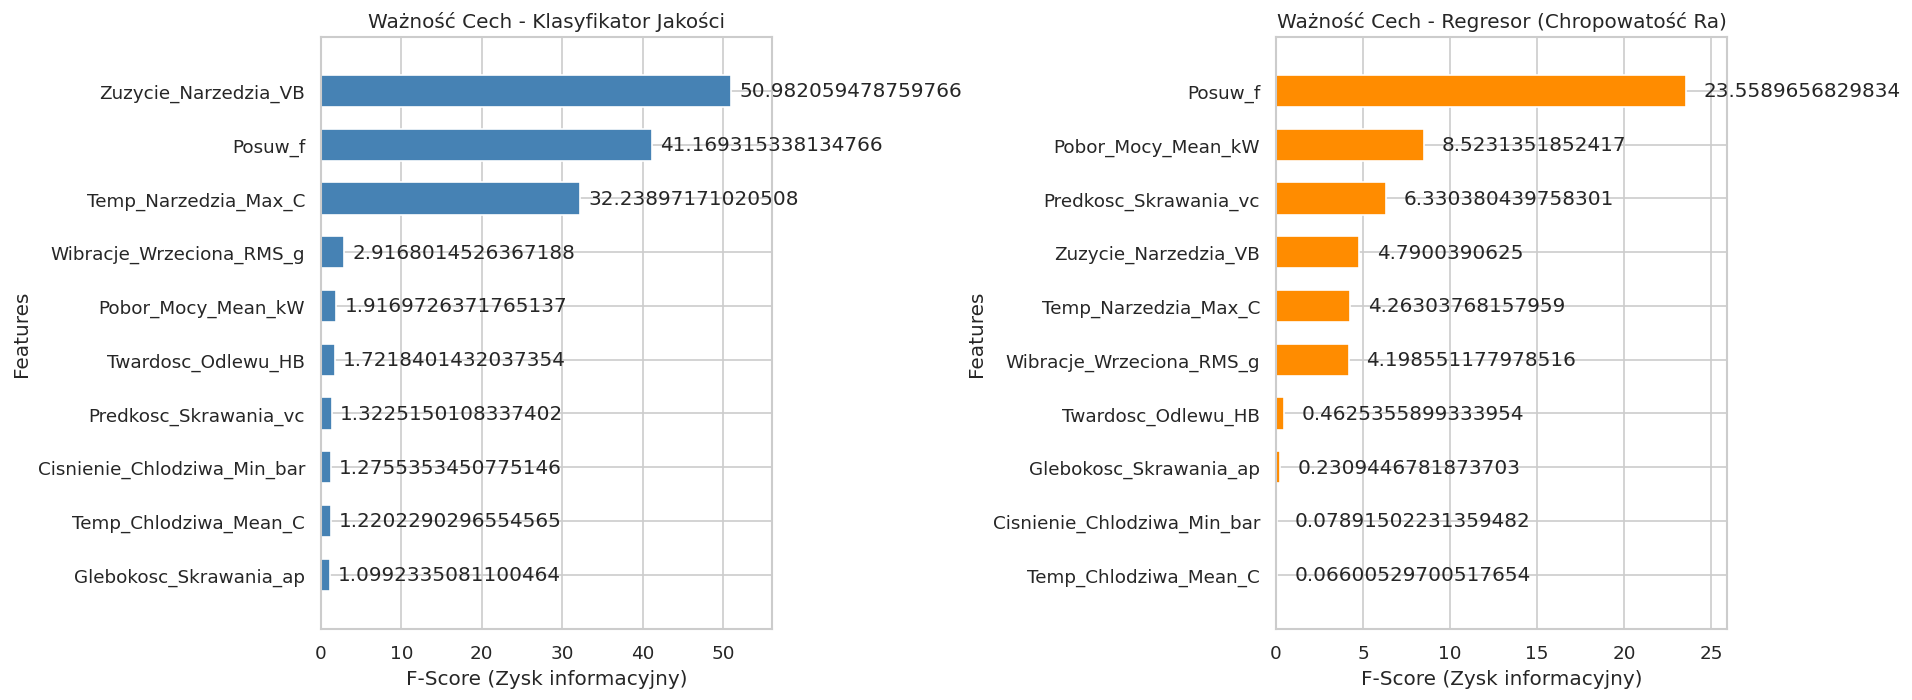

Modelowanie zakończone! Wykres zapisany jako 'waznosc_cech_xgboost.png'.
Generowanie wykresów ewaluacyjnych...


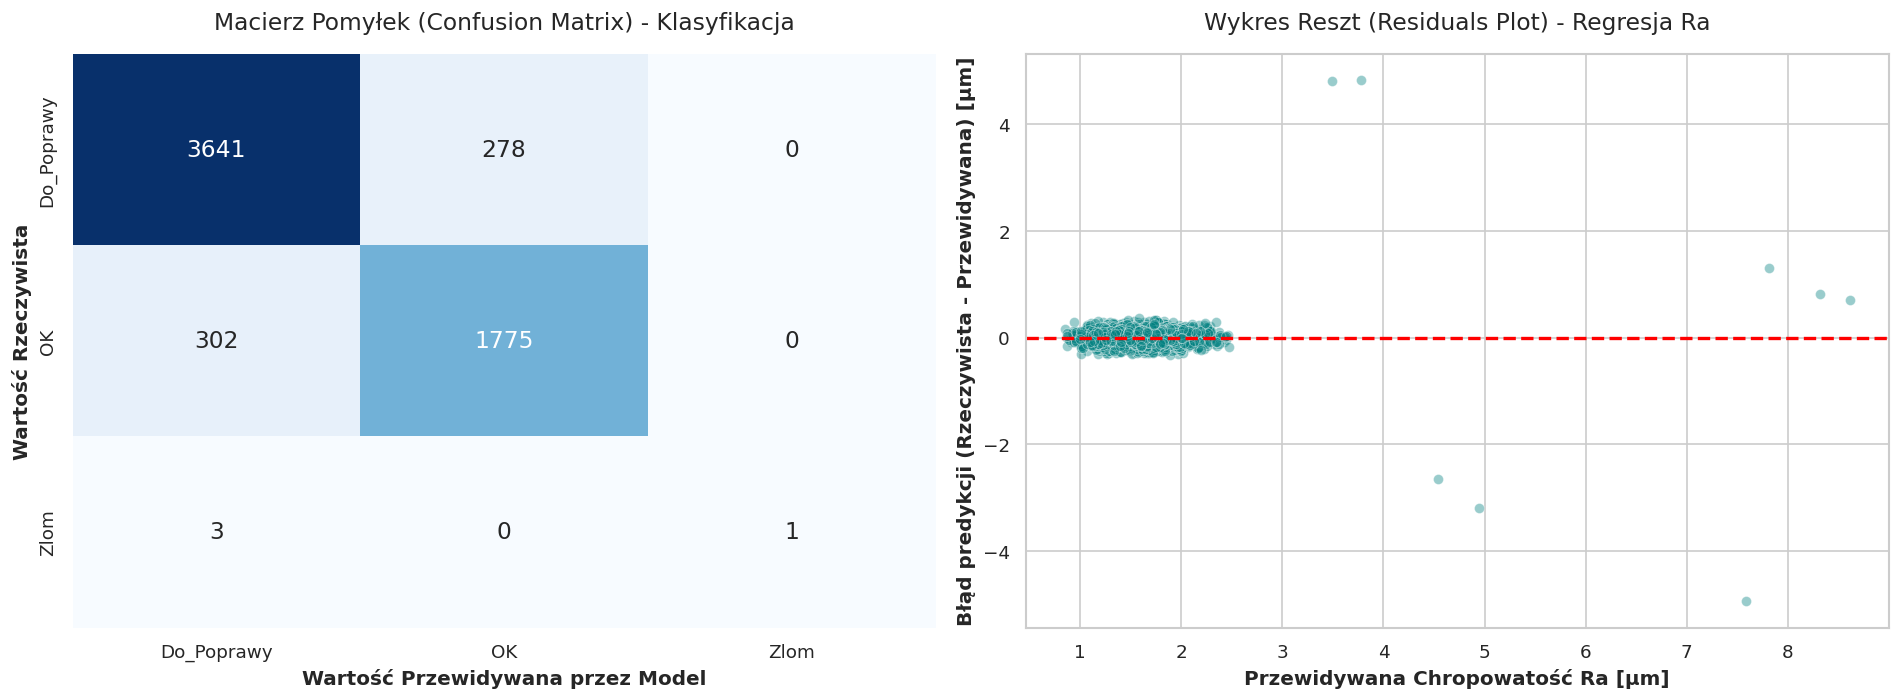

Zakończono! Wykres zapisany jako 'wykresy_ewaluacyjne.png'.


In [9]:
train_models()